# Ticketmaster Discovery API — GB Music Genre Analysis

Vantage Talent brief: mapping genre-level touring patterns to identify market
opportunity for a mid-tier act.

**Method summary**
- Fetch GB Music events in **weekly date windows** (exhaustive, non-overlapping)
  rather than by city or genre, so nothing is excluded at fetch time.
- Deduplicate on `attraction_id` when counting *acts* — a three-night run is
  three events but one act.
- Measure saturation with a **location quotient**: a city's share of a genre
  divided by the national share. LQ > 1 = over-indexed, LQ < 1 = underserved.

## 1. Setup

In [5]:
import json
import time
import datetime as dt
from pathlib import Path

import requests
import pandas as pd

import os
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("API_KEY")

# NOTE: rotate this key in the Ticketmaster developer console before submitting.
# Better practice: API_KEY = os.environ["TM_API_KEY"]

COUNTRY = "GB"
SEGMENT = "Music"
N_WEEKS = 26          # analysis horizon; check the retrieval plot before trusting the tail

## 2. Helpers

In [6]:
def first(items, *path):
    """Walk a path of keys through the first dict in a list.

    Used for `classifications`, `_embedded.venues` and `_embedded.attractions`,
    which json_normalize leaves as raw lists.
    """
    if not isinstance(items, list) or not items:
        return None
    node = items[0]
    for key in path:
        node = (node or {}).get(key)
    return node


def fetch_window(start, end, max_pages=5, pause=0.25):
    """Fetch all events in one date window.

    Returns (events, total_reported). `total_reported` comes from the API's own
    count for the query scope, so comparing it against len(events) tells you
    whether the window was truncated by the 1000-record ceiling.
    """
    out, total = [], None
    for page in range(max_pages):
        r = requests.get(
            "https://app.ticketmaster.com/discovery/v2/events.json",
            params={
                "apikey": API_KEY, "size": 200, "page": page,
                "countryCode": COUNTRY, "segmentName": SEGMENT,
                "startDateTime": start, "endDateTime": end,
            },
            timeout=30,
        )
        r.raise_for_status()
        payload = r.json()
        if total is None:
            total = payload.get("page", {}).get("totalElements", 0)
        batch = payload.get("_embedded", {}).get("events", [])
        if not batch:
            break
        out.extend(batch)
        # page * size must stay under 1000
        if len(out) >= total or (page + 1) * 200 >= 1000:
            break
        time.sleep(pause)
    return out, total

## 3. Test a single window first

If `len(ev)` matches `total`, weekly windows are fine. If `total` is much larger,
the week is truncated and needs splitting into daily windows.

In [7]:
ev, total = fetch_window("2026-10-01T00:00:00Z", "2026-10-08T00:00:00Z")
len(ev), total

(483, 483)

## 4. The sweep

Set `N_WEEKS = 4` in Cell 1 the first time to confirm it runs before committing
to the full pull (which takes a couple of minutes).

In [8]:
start_date = dt.date.today()

all_events, log = [], []

for i in range(N_WEEKS):
    w = start_date + dt.timedelta(days=7 * i)
    s = f"{w}T00:00:00Z"
    e = f"{w + dt.timedelta(days=7)}T00:00:00Z"

    ev, total = fetch_window(s, e)
    all_events.extend(ev)
    log.append({
        "week": str(w),
        "retrieved": len(ev),
        "reported": total,
        "truncated": total > len(ev),
    })
    time.sleep(0.25)

log_df = pd.DataFrame(log)
print(f"{len(all_events)} events collected, {log_df.truncated.sum()} windows truncated")
log_df

8783 events collected, 0 windows truncated


,week,retrieved,reported,truncated
0,2026-08-06,216,216,False
1,2026-08-13,221,221,False
2,2026-08-20,276,276,False
3,2026-08-27,382,382,False
4,2026-09-03,339,339,False
5,2026-09-10,388,388,False
6,2026-09-17,417,417,False
7,2026-09-24,444,444,False
8,2026-10-01,483,483,False
9,2026-10-08,585,585,False


### Retrieval by week

Counts hold steady for a few months then fall away. That drop-off is the
**announcement horizon**, not a seasonal lull — events past it simply are not
listed yet. Cap the analysis before the cliff and state that assumption.

<Axes: title={'center': 'Events retrieved per weekly window'}, xlabel='week'>

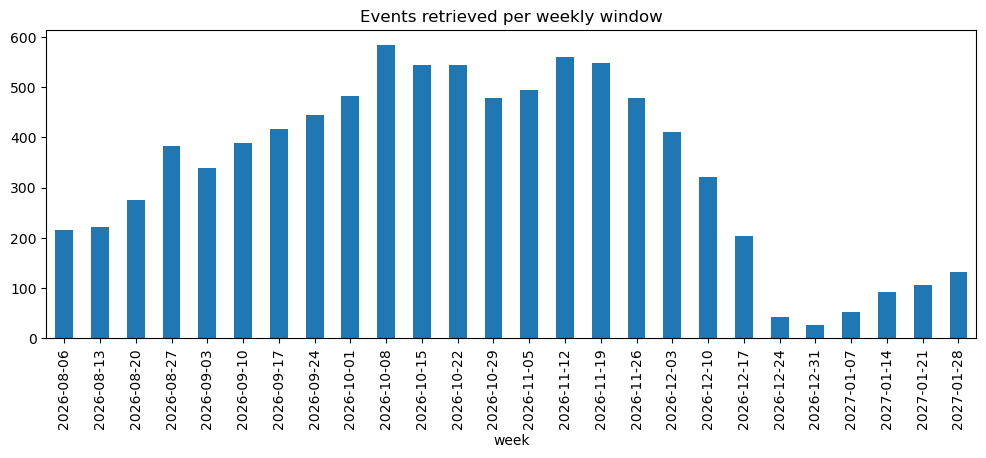

In [9]:
log_df.plot(x="week", y="retrieved", kind="bar", figsize=(12, 4), legend=False,
            title="Events retrieved per weekly window")

## 5. Store the raw response

Written before any transformation, so fields can be re-derived without re-hitting
the API.

In [10]:
Path("data/raw").mkdir(parents=True, exist_ok=True)
raw_path = Path(f"data/raw/events_{dt.date.today()}.json")
raw_path.write_text(json.dumps(all_events))
print(f"{len(all_events)} raw records -> {raw_path}")

8783 raw records -> data/raw/events_2026-08-06.json


## 6. Flatten

In [11]:
df = pd.json_normalize(all_events)

df["genre"]           = df["classifications"].apply(lambda c: first(c, "genre", "name"))
df["subgenre"]        = df["classifications"].apply(lambda c: first(c, "subGenre", "name"))
df["city"]            = df["_embedded.venues"].apply(lambda v: first(v, "city", "name"))
df["attraction_id"]   = df["_embedded.attractions"].apply(lambda a: first(a, "id"))
df["attraction_name"] = df["_embedded.attractions"].apply(lambda a: first(a, "name"))
df["event_date"]      = pd.to_datetime(df["dates.start.localDate"], errors="coerce")

df.shape

(8783, 85)

### Fields checked and unavailable

`priceRanges` was **absent for all 8,685 events** in the GB pull, so price-tier
analysis (matching opportunity to an act's scale) was not possible. Recorded here
as a checked limitation rather than an oversight.

`test` — Ticketmaster's own test records — returned zero, so no filtering needed.

In [12]:
print("events carrying priceRanges:",
      sum("priceRanges" in e for e in all_events), "/", len(all_events))
print("test records:", sum(e.get("test", False) for e in all_events))
sorted(all_events[0].keys())

events carrying priceRanges: 0 / 8783
test records: 0


['_embedded',
 '_links',
 'classifications',
 'dates',
 'description',
 'id',
 'images',
 'locale',
 'name',
 'nameOrigin',
 'sales',
 'test',
 'type',
 'url']

## 7. Cleaning

Deliberately minimal. Only fixes that are true regardless of which rows we happen
to have:

- **Duplicate ids** — a multi-date run can surface in more than one window.
- **`"Undefined"`** is Ticketmaster's null, delivered as a literal string.
- **City casing** — the API mixes `upon` / `Upon` in "Newcastle Upon Tyne".

Nothing count-driven happens here (no collapsing rare genres, no dropping thin
cities). Those are analysis-time decisions and would otherwise bake this pull's
composition into everything downstream.

In [45]:
def clean_events(raw_df):
    cols = ["id", "name", "genre", "subgenre", "city",
            "attraction_id", "attraction_name", "event_date"]
    out = raw_df[cols].copy()
    out = out.drop_duplicates(subset="id")

    text = ["genre", "subgenre", "city", "attraction_name"]
    out[text] = out[text].apply(lambda s: s.str.strip()).replace("Undefined", pd.NA)

    # Some venues append a postcode or trailing comma to the city field
    # (e.g. "Newcastle Upon Tyne, NE1 2PQ"), splitting one city across two
    # buckets. Drop anything after the first comma, then normalise case.
    out["city"] = (out["city"]
                   .str.split(",").str[0]
                   .str.strip()
                   .str.title())
    return out


clean = clean_events(df)
clean.shape

(8766, 8)

## 8. Data quality checks

`Other` and `<NA>` are kept as distinct: `Other` is a real Ticketmaster label
(unclassified), `<NA>` means no classification was returned at all. Neither is
dropped from `clean` — the null rate is itself a finding the brief asks for.

In [46]:
clean.isna().sum()

id                   0
name                 0
genre              655
subgenre           655
city                 0
attraction_id      328
attraction_name    328
event_date           0
dtype: int64

In [47]:
clean["genre"].value_counts(dropna=False)

genre
Rock                 3985
Pop                  1039
<NA>                  655
Dance/Electronic      417
Metal                 402
Jazz                  364
Alternative           332
R&B                   323
Folk                  321
Hip-Hop/Rap           244
Country               184
Other                 153
Reggae                 93
World                  89
Classical              75
Blues                  49
Latin                  14
Holiday                 9
Religious               8
New Age                 5
Ballads/Romantic        2
Children's Music        2
Chanson Francaise       1
Name: count, dtype: int64

### Genre and sub-genre are not a clean hierarchy

Sub-genre labels repeat across parent genres (e.g. `Pop` appears under both
`Pop` and `Rock`), so **always group by the pair**, never by sub-genre alone.

In [48]:
pd.crosstab(clean["genre"], clean["subgenre"], dropna=False)

subgenre,A Cappella,Acoustic Blues,Adult Alternative Pop/Rock,Adult Contemporary,African,Afro-Beat,Alternative,Alternative Dance,Alternative Folk,Alternative Rap,...,Traditional Folk,Trap,Trip Hop,Urban,Urban Adult Contemporary,World,World Dance,World Rock,Worldbeat,NaN
genre,,,,,,,,,,,,,,,,,,,,,
Alternative,0,0,35,0,0,0,84,5,0,0,...,0,0,0,0,0,0,0,0,0,0
Ballads/Romantic,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Blues,0,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Chanson Francaise,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Children's Music,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Classical,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Country,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Dance/Electronic,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,3,0,0,0
Folk,1,0,0,0,0,0,0,0,6,0,...,1,0,0,0,0,0,0,0,0,0


### Is missing genre random?

If unclassified events cluster in particular cities, dropping them biases the
genre shares. Worth checking before excluding anything.

In [49]:
(clean.assign(no_genre=clean["genre"].isna() | (clean["genre"] == "Other"))
      .groupby("city")["no_genre"].mean()
      .sort_values(ascending=False).head(10))

city
Kendal           1.0
Isle Of Man      1.0
Malta            1.0
Middlesbrough    1.0
Ramsgate         1.0
Redruth          1.0
Rhyl             1.0
Gillingham       1.0
Cheshire         1.0
Shrewsbury       1.0
Name: no_genre, dtype: float64

## 9. Analysis bases

Filtering happens here, not in `clean_events`, so `clean` stays the full record.

- `local` — one row per **act per city** (an act touring 3 cities counts in each)
- `national` — one row per **act** overall

In [50]:
genre_known = clean[clean["genre"].notna() & (clean["genre"] != "Other")]

base = genre_known.dropna(subset=["attraction_id"])
local = base.drop_duplicates(subset=["attraction_id", "city"])
national = base.drop_duplicates(subset="attraction_id")

len(base), len(local), len(national)

(7708, 6282, 2560)

### Events vs acts per city

Where events far exceed acts, a few multi-night residencies dominate. That is the
mechanism that would distort genre share if events were counted naively.

In [51]:
events_per_city = clean.groupby("city").size()
acts_per_city = local.groupby("city").size()

(pd.DataFrame({"events": events_per_city, "acts": acts_per_city})
   .fillna(0).astype(int)
   .assign(events_per_act=lambda d: (d.events / d.acts).round(2))
   .sort_values("events", ascending=False))

,events,acts,events_per_act
city,,,
London,2439,1366,1.79
Glasgow,801,621,1.29
Manchester,715,619,1.16
Birmingham,403,335,1.20
Leeds,368,284,1.30
...,...,...,...
Omagh,1,1,1.00
Oban,1,1,1.00
Ballymena,1,1,1.00


## 10. Location quotient

$$LQ = \frac{\text{genre acts in city} \;/\; \text{all acts in city}}
{\text{genre acts nationally} \;/\; \text{all acts nationally}}$$

- **LQ > 1** — the city over-indexes on this genre (saturated)
- **LQ < 1** — underserved relative to the national footprint

**Read `total_acts` before reading `lq`.** A city with 2 acts can only produce
LQ values of 0, ~1.6 or ~3.2 — the measure has no resolution below roughly 10
acts. `min_acts` exists to keep that limitation visible.

**Baseline:** the national figure is computed *from this pull*, not from GB
overall. State that explicitly.

In [52]:
def location_quotient(genre, min_acts=1):
    """Genre concentration by city, relative to the national share in this pull."""
    nat_share = (national["genre"] == genre).mean()

    out = local.groupby("city").agg(
        genre_acts=("genre", lambda g: (g == genre).sum()),
        total_acts=("genre", "size"),
    )
    out["city_share"] = (out["genre_acts"] / out["total_acts"]).round(3)
    out["lq"] = (out["city_share"] / nat_share).round(2)

    print(f"National {genre} share: {nat_share:.1%}")
    return out[out["total_acts"] >= min_acts].sort_values("lq", ascending=False)


location_quotient("Rock")

National Rock share: 44.7%


,genre_acts,total_acts,city_share,lq
city,,,,
Chelmsford,1,1,1.0,2.24
Cowdenbeath,1,1,1.0,2.24
Canterbury,4,4,1.0,2.24
Grays,1,1,1.0,2.24
Henley-On-Thames,1,1,1.0,2.24
...,...,...,...,...
High Wycombe,0,1,0.0,0.00
Fochabers,0,1,0.0,0.00
Strathpeffer,0,1,0.0,0.00


Genre strings are case-sensitive and exact — `"Hip-Hop/Rap"`, not `"Hip Hop"`. A national share of 0.0% means the string did not match.

In [53]:
location_quotient("Rock", min_acts=100)

National Rock share: 44.7%


,genre_acts,total_acts,city_share,lq
city,,,,
Liverpool,88,127,0.693,1.55
Nottingham,98,141,0.695,1.55
Edinburgh,79,120,0.658,1.47
Southampton,101,160,0.631,1.41
Cardiff,70,116,0.603,1.35
Belfast,128,220,0.582,1.30
Newcastle Upon Tyne,118,204,0.578,1.29
Glasgow,347,621,0.559,1.25
Bristol,141,271,0.520,1.16


In [54]:
location_quotient("Pop", min_acts=10)

National Pop share: 9.7%


,genre_acts,total_acts,city_share,lq
city,,,,
Ipswich,3,11,0.273,2.81
Truro,3,12,0.250,2.57
Gateshead,4,21,0.190,1.95
Halifax,2,12,0.167,1.72
Southend-On-Sea,4,24,0.167,1.72
Leicester,6,36,0.167,1.72
Torquay,2,13,0.154,1.58
Morecambe,3,20,0.150,1.54
Bath,3,20,0.150,1.54


### All genres at once

Sorted by `total_acts` rather than by any LQ column, so the cities with enough
data to interpret appear first.

In [55]:
lq_matrix = {}
for g in sorted(national["genre"].dropna().unique()):
    share = (national["genre"] == g).mean()
    lq_matrix[g] = (local.groupby("city")["genre"]
                         .apply(lambda s, g=g: (s == g).mean()) / share).round(2)

lq_all = pd.DataFrame(lq_matrix).fillna(0)
lq_all["total_acts"] = local.groupby("city").size()
lq_all.sort_values("total_acts", ascending=False)

,Alternative,Ballads/Romantic,Blues,Chanson Francaise,Children's Music,Classical,Country,Dance/Electronic,Folk,Hip-Hop/Rap,...,Latin,Metal,New Age,Pop,R&B,Reggae,Religious,Rock,World,total_acts
city,,,,,,,,,,,,,,,,,,,,,
London,0.71,1.87,0.82,0.00,1.87,0.82,0.79,0.98,0.46,1.28,...,1.25,1.21,1.41,1.08,1.39,1.45,1.12,0.91,1.41,1366
Glasgow,0.69,0.00,0.00,4.12,0.00,1.29,1.47,0.54,1.08,1.02,...,0.00,1.49,0.00,1.01,0.53,0.31,0.00,1.25,0.32,621
Manchester,1.06,0.00,0.33,0.00,0.00,1.81,1.19,0.80,0.78,1.58,...,0.92,1.01,1.03,1.20,0.83,0.31,0.00,1.12,0.48,619
Birmingham,0.44,0.00,0.00,0.00,0.00,1.43,1.30,0.65,0.33,1.63,...,0.85,1.72,0.00,1.26,0.92,1.72,0.00,1.11,0.73,335
Leeds,2.02,0.00,1.08,0.00,0.00,1.69,0.76,0.77,1.24,1.01,...,0.00,0.80,2.25,0.87,0.50,0.45,0.00,1.13,0.00,284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Bolton,0.00,0.00,0.00,0.00,0.00,160.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1
Scunthorpe,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.24,0.00,1
Bilston,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.24,0.00,1


## 11. Shortlist — where does opportunity actually look viable?

Combines the two dimensions. `total_acts` is a **reliability filter**, not part of
the signal: below roughly 10 acts an LQ can swing on a single booking.

- **High `total_acts`, low LQ** — an active market thin in this genre. The cell of
  interest.
- **Low `total_acts`, low LQ** — mostly "nobody plays anything here", which is a
  demand problem rather than an opening.

In [56]:
def shortlist(genre, min_acts=50):
    """Cities ranked by how underserved they are in `genre`, reliable rows only."""
    lq = location_quotient(genre, min_acts=min_acts)
    return lq.sort_values("lq")


shortlist("Rock")

National Rock share: 44.7%


,genre_acts,total_acts,city_share,lq
city,,,,
London,558,1366,0.408,0.91
Manchester,310,619,0.501,1.12
Birmingham,167,335,0.499,1.12
Brighton,77,152,0.507,1.13
Leeds,144,284,0.507,1.13
Bristol,141,271,0.520,1.16
York,41,74,0.554,1.24
Glasgow,347,621,0.559,1.25
Newcastle Upon Tyne,118,204,0.578,1.29


### How many cities can the analysis actually speak to?

Whatever clears the `min_acts` bar is the real scope of the answer. Everything
below it stays noise however the LQ falls.

In [57]:
acts = local.groupby("city").size().sort_values(ascending=False)
print(f"{(acts >= 10).sum()} cities with >=10 acts, out of {len(acts)}")
acts.head(30)

57 cities with >=10 acts, out of 198


city
London                 1366
Glasgow                 621
Manchester              619
Birmingham              335
Leeds                   284
Bristol                 271
Belfast                 220
Newcastle Upon Tyne     204
Southampton             160
Brighton                152
Nottingham              141
Liverpool               127
Edinburgh               120
Cardiff                 116
Sheffield                96
York                     74
Oxford                   74
Wolverhampton            56
Bournemouth              55
Derby                    54
Norwich                  53
Leicester                36
Aberdeen                 36
Cambridge                35
Portsmouth               34
Cumbria                  31
Hertford                 30
Kinross                  29
St Albans                27
Exeter                   26
dtype: int64

## 12. Seasonality

The brief's third question — competitive windows to target or avoid. Interpret
only within the announcement horizon identified in the retrieval plot above.

In [58]:
monthly = (genre_known.assign(month=genre_known["event_date"].dt.to_period("M"))
                      .groupby(["month", "genre"]).size()
                      .unstack(fill_value=0))
monthly

genre,Alternative,Ballads/Romantic,Blues,Chanson Francaise,Children's Music,Classical,Country,Dance/Electronic,Folk,Hip-Hop/Rap,...,Jazz,Latin,Metal,New Age,Pop,R&B,Reggae,Religious,Rock,World
month,,,,,,,,,,,,,,,,,,,,,
2026-08,44,0,3,0,0,17,25,77,29,27,...,88,2,25,1,123,56,23,1,328,12
2026-09,74,0,19,0,0,17,33,81,56,44,...,104,5,67,0,194,43,11,2,750,21
2026-10,82,0,7,1,0,12,51,135,107,77,...,103,2,119,4,258,89,26,4,1144,25
2026-11,96,2,11,0,0,11,50,84,71,51,...,58,1,94,0,278,96,17,1,1078,16
2026-12,31,0,1,0,2,18,15,34,52,43,...,10,4,39,0,107,36,14,0,547,15
2027-01,4,0,8,0,0,0,9,5,6,2,...,1,0,57,0,73,1,1,0,118,0
2027-02,1,0,0,0,0,0,1,1,0,0,...,0,0,1,0,6,2,1,0,20,0


## 13. Caveats to carry into the presentation

1. **Listed ≠ scheduled.** The API returns announced events only. Apparent
   sparsity in later months is an artefact of the onsale calendar.
2. **Baseline is internal.** LQ compares each city against the national average
   *within this pull*.
3. **Truncation.** Any window flagged in `log_df` is incomplete and should be
   re-fetched at daily granularity.
4. **Small samples.** Most cities carry too few acts for a stable LQ; the
   `min_acts` floor is a visible guard, not a fix.
5. **No price data.** `priceRanges` was absent for all 8,685 events, so the
   analysis cannot distinguish a £15 club show from a £60 arena date. A genre can
   look thin in a city while being thin only at a scale the act does not play.
6. **Underserved ≠ opportunity.** A low LQ identifies a gap. Gaps need a
   demand-side explanation before they become recommendations — ONS population
   normalisation is the cheapest partial check.

In [59]:
eid = all_events[0]["id"]
r = requests.get(
    f"https://app.ticketmaster.com/discovery/v2/events/{eid}.json",
    params={"apikey": API_KEY}, timeout=30,
)
"priceRanges" in r.json()

False

In [60]:
r = requests.get(
    "https://app.ticketmaster.com/discovery/v2/events.json",
    params={"apikey": API_KEY, "size": 20, "countryCode": "US",
            "segmentName": "Music"}, timeout=30,
)
sum("priceRanges" in e for e in r.json()["_embedded"]["events"])

0

National Dance/Electronic share: 6.9%


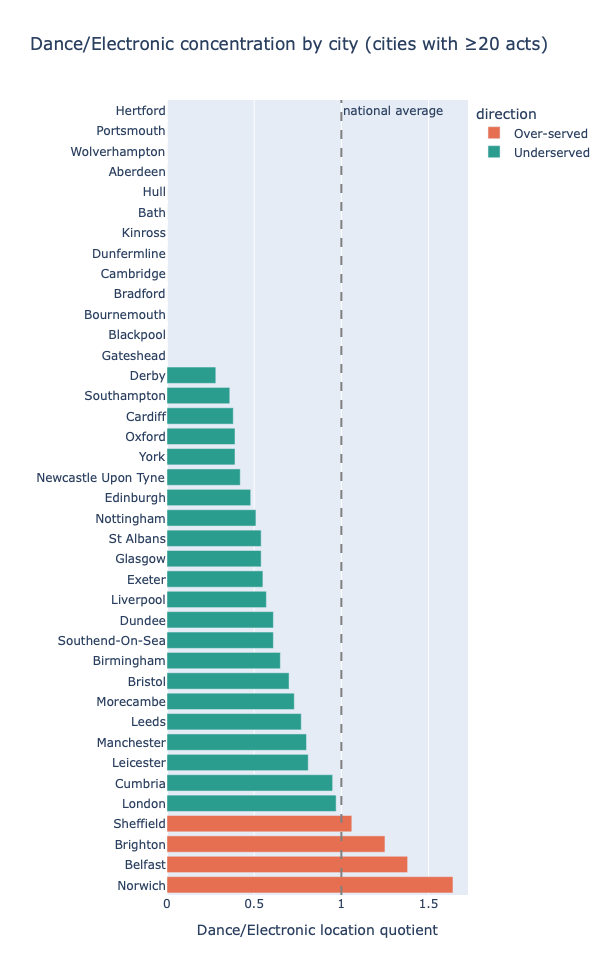

In [68]:
import plotly.express as px

def plot_lq(genre, min_acts=20):
    d = location_quotient(genre, min_acts=min_acts).reset_index()
    d["direction"] = d["lq"].apply(lambda x: "Over-served" if x > 1 else "Underserved")

    fig = px.bar(
        d.sort_values("lq", ascending=False),
        x="lq", y="city", orientation="h",
        color="direction",
        color_discrete_map={"Underserved": "#2a9d8f", "Over-served": "#e76f51"},
        hover_data={"genre_acts": True, "total_acts": True, "lq": ":.2f", "direction": False},
        labels={"lq": f"{genre} location quotient", "city": ""},
        title=f"{genre} concentration by city (cities with ≥{min_acts} acts)",
    )
    fig.add_vline(x=1, line_dash="dash", line_color="grey",
                  annotation_text="national average")
    fig.update_layout(height=max(400, 25 * len(d)), showlegend=True)
    return fig

plot_lq("Dance/Electronic").show()

In [62]:
lq = location_quotient("Rock", min_acts=50)
print(len(lq), "cities")
lq

National Rock share: 44.7%
21 cities


,genre_acts,total_acts,city_share,lq
city,,,,
Derby,42,54,0.778,1.74
Liverpool,88,127,0.693,1.55
Nottingham,98,141,0.695,1.55
Wolverhampton,37,56,0.661,1.48
Oxford,49,74,0.662,1.48
Edinburgh,79,120,0.658,1.47
Bournemouth,36,55,0.655,1.46
Southampton,101,160,0.631,1.41
Norwich,33,53,0.623,1.39


In [66]:
clean["genre"].value_counts(dropna=False)

genre
Rock                 3985
Pop                  1039
<NA>                  655
Dance/Electronic      417
Metal                 402
Jazz                  364
Alternative           332
R&B                   323
Folk                  321
Hip-Hop/Rap           244
Country               184
Other                 153
Reggae                 93
World                  89
Classical              75
Blues                  49
Latin                  14
Holiday                 9
Religious               8
New Age                 5
Ballads/Romantic        2
Children's Music        2
Chanson Francaise       1
Name: count, dtype: int64